# Поиск ассоциативных правил (продолжение Apriori)

Лабораторная работа №2 по дисциплине **«Основы интеллектуального анализа данных»**.
Дорабатываем программу из работы №1 (поиск частых наборов алгоритмом Apriori):
теперь по найденным частым наборам строим **ассоциативные правила** вида
`антецедент → консеквент` с указанием **поддержки** и **достоверности** каждого правила.

Параметры программы:

1. набор данных (список транзакций `baskets.csv`);
2. порог поддержки `min_support` (фиксируем);
3. порог достоверности `min_confidence` (варьируем);
4. способ упорядочивания результата: по убыванию поддержки или лексикографически.

План экспериментов:

- **Часть А (проверочная):** фиксируем поддержку 10% (как в примере задания),
  варьируем достоверность 70-95% с шагом 5% - показываем, что на этом плотном
  наборе данных правил с такой высокой достоверностью нет;
- **Часть Б (основная):** фиксируем поддержку 2%, варьируем достоверность
  20-50% с шагом 5% - получаем содержательные кривые и список правил.

Визуализация:

- быстродействие поиска правил при изменяемом пороге достоверности;
- общее количество найденных правил при изменяемом пороге достоверности.


In [1]:
import csv
import time
from collections import defaultdict, Counter
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = "baskets.csv"


## 1. Загрузка данных

Файл `baskets.csv` - тот же, что в работе №1: 7501 чек супермаркета,
каждая строка - набор товаров через запятую, без заголовка, кодировка `cp1251`.


In [2]:
def load_transactions(path, encoding="cp1251"):
    """Читает csv с транзакциями и возвращает список наборов товаров."""
    transactions = []
    with open(path, encoding=encoding) as f:
        reader = csv.reader(f)
        for row in reader:
            items = frozenset(x.strip() for x in row if x.strip())
            if items:
                transactions.append(items)
    return transactions


transactions = load_transactions(DATA_PATH)

all_items = set().union(*transactions)
lengths = [len(t) for t in transactions]

print(f"Число транзакций: {len(transactions)}")
print(f"Число уникальных товаров: {len(all_items)}")
print(f"Средняя длина транзакции: {sum(lengths) / len(lengths):.2f}")
print(f"Максимальная длина транзакции: {max(lengths)}")


Число транзакций: 7501
Число уникальных товаров: 115
Средняя длина транзакции: 3.91
Максимальная длина транзакции: 20


## 2. Алгоритм Apriori (из работы №1 без изменений)

Коротко напоминаем идею:

1. Находим частые наборы из одного товара (подсчёт частот + порог).
2. Пока есть частые наборы предыдущего размера: строим кандидатов следующего
   размера и отбрасываем тех, у кого есть нечастое подмножество;
   считаем поддержку кандидатов по транзакциям, оставляем прошедших порог.
3. Собираем все частые наборы вместе.

Функции ниже - те же, что в `apriori_market_basket.ipynb` из работы №1.


In [3]:
def get_frequent_items(transactions, min_count):
    """Находит частые наборы из одного товара."""
    counts = defaultdict(int)
    for transaction in transactions:
        for item in transaction:
            counts[item] += 1

    return {frozenset([item]): count for item, count in counts.items()
            if count >= min_count}


def generate_candidates(frequent_itemsets, size):
    """Строит кандидатов заданного размера из уже найденных частых наборов."""
    items = set()
    for itemset in frequent_itemsets:
        items.update(itemset)

    candidates = set()
    for combo in combinations(sorted(items), size):
        candidate = frozenset(combo)
        subsets = combinations(candidate, size - 1)
        if all(frozenset(subset) in frequent_itemsets for subset in subsets):
            candidates.add(candidate)

    return candidates


def count_support(transactions, candidates):
    """Считает, сколько раз каждый кандидат встречается в транзакциях."""
    counts = defaultdict(int)
    for transaction in transactions:
        for candidate in candidates:
            if candidate <= transaction:
                counts[candidate] += 1
    return counts


def apriori(transactions, min_support, sort_by="support_desc"):
    """
    Поиск частых наборов объектов методом Apriori.

    transactions: список транзакций (наборов товаров)
    min_support: порог поддержки, доля от 0 до 1 (например, 0.02 = 2%)
    sort_by: "support_desc" (по убыванию поддержки) или "lexicographic"

    Возвращает список пар (набор объектов, значение поддержки).
    """
    n = len(transactions)
    min_count = min_support * n

    frequent_itemsets = get_frequent_items(transactions, min_count)
    all_frequent = dict(frequent_itemsets)

    size = 2
    while frequent_itemsets:
        candidates = generate_candidates(frequent_itemsets, size)
        if not candidates:
            break

        counts = count_support(transactions, candidates)
        frequent_itemsets = {itemset: count for itemset, count in counts.items()
                             if count >= min_count}

        all_frequent.update(frequent_itemsets)
        size += 1

    results = [(itemset, count / n) for itemset, count in all_frequent.items()]

    if sort_by == "support_desc":
        results.sort(key=lambda pair: (-pair[1], sorted(pair[0])))
    elif sort_by == "lexicographic":
        results.sort(key=lambda pair: sorted(pair[0]))
    else:
        raise ValueError("sort_by должен быть 'support_desc' или 'lexicographic'")

    return results


## 3. Генерация ассоциативных правил

Для каждого частого набора длины ≥ 2 перебираем все непустые собственные
подмножества как антецеденты. Консеквент - дополнение до полного набора.

- поддержка правила `A → C` = поддержка объединения `A ∪ C`;
- достоверность `conf(A → C)` = `support(A ∪ C) / support(A)`.

Оставляем правила с достоверностью не ниже порога. Сортировка результата -
тем же параметром, что в работе №1: по убыванию поддержки либо
лексикографически (для детерминированности вывода).


In [4]:
def generate_rules(frequent_list, min_confidence, sort_by="support_desc"):
    """
    Строит ассоциативные правила по списку частых наборов.

    frequent_list: список пар (набор, поддержка) - выход функции apriori
    min_confidence: порог достоверности, доля от 0 до 1 (например, 0.3 = 30%)
    sort_by: "support_desc" или "lexicographic"

    Возвращает список кортежей (антецедент, консеквент, поддержка, достоверность).
    """
    support_of = {itemset: support for itemset, support in frequent_list}

    rules = []
    for itemset, support in frequent_list:
        if len(itemset) < 2:
            continue
        for size in range(1, len(itemset)):
            for antecedent in combinations(itemset, size):
                antecedent = frozenset(antecedent)
                consequent = itemset - antecedent
                confidence = support / support_of[antecedent]
                if confidence >= min_confidence:
                    rules.append((antecedent, consequent, support, confidence))

    if sort_by == "support_desc":
        rules.sort(key=lambda r: (-r[2], -r[3], sorted(r[0]), sorted(r[1])))
    elif sort_by == "lexicographic":
        rules.sort(key=lambda r: (sorted(r[0]), sorted(r[1])))
    else:
        raise ValueError("sort_by должен быть 'support_desc' или 'lexicographic'")

    return rules


def format_rule(antecedent, consequent, support, confidence):
    """Удобочитаемая строка правила: {A} -> {C} (support=..., confidence=...)."""
    left = "{" + ", ".join(sorted(antecedent)) + "}"
    right = "{" + ", ".join(sorted(consequent)) + "}"
    return f"{left} -> {right}  support={support:.4f}  confidence={confidence:.4f}"


## 4. Пробный запуск

Фиксируем поддержку 2%, достоверность 30%: печатаем найденные правила
в обоих режимах сортировки. Все правила здесь короткие
(антецедент + консеквент = 2 объекта, что заведомо ≤ 7).


In [5]:
frequent_002 = apriori(transactions, min_support=0.02, sort_by="support_desc")
print(f"Частых наборов при поддержке 2%: {len(frequent_002)}")

demo_rules = generate_rules(frequent_002, min_confidence=0.30, sort_by="support_desc")
print(f"Найдено {len(demo_rules)} правил при достоверности 30% (сортировка по поддержке):\n")
for ant, cons, sup, conf in demo_rules:
    print("  " + format_rule(ant, cons, sup, conf))


Частых наборов при поддержке 2%: 104
Найдено 21 правил при достоверности 30% (сортировка по поддержке):

  {макароны} -> {минеральная вода}  support=0.0612  confidence=0.3255
  {шоколад} -> {минеральная вода}  support=0.0527  confidence=0.3214
  {молоко} -> {минеральная вода}  support=0.0480  confidence=0.3704
  {говяжий фарш} -> {минеральная вода}  support=0.0409  confidence=0.4166
  {говяжий фарш} -> {макароны}  support=0.0403  confidence=0.4098
  {замороженные овощи} -> {минеральная вода}  support=0.0357  confidence=0.3748
  {блинчики} -> {минеральная вода}  support=0.0337  confidence=0.3548
  {гамбургер} -> {яйца}  support=0.0288  confidence=0.3303
  {оливковое масло} -> {минеральная вода}  support=0.0276  confidence=0.4190
  {торт} -> {минеральная вода}  support=0.0275  confidence=0.3388
  {рис} -> {минеральная вода}  support=0.0273  confidence=0.3596
  {креветки} -> {макароны}  support=0.0252  confidence=0.3526
  {помидоры} -> {минеральная вода}  support=0.0244  confidence=0.3567

In [6]:
demo_lex = generate_rules(frequent_002, min_confidence=0.30, sort_by="lexicographic")
print("Те же правила, лексикографическая сортировка (первые 10):\n")
for ant, cons, sup, conf in demo_lex[:10]:
    print("  " + format_rule(ant, cons, sup, conf))


Те же правила, лексикографическая сортировка (первые 10):

  {блинчики} -> {минеральная вода}  support=0.0337  confidence=0.3548
  {гамбургер} -> {яйца}  support=0.0288  confidence=0.3303
  {говяжий фарш} -> {макароны}  support=0.0403  confidence=0.4098
  {говяжий фарш} -> {минеральная вода}  support=0.0409  confidence=0.4166
  {замороженные овощи} -> {минеральная вода}  support=0.0357  confidence=0.3748
  {замороженный смузи} -> {минеральная вода}  support=0.0203  confidence=0.3200
  {креветки} -> {макароны}  support=0.0252  confidence=0.3526
  {креветки} -> {минеральная вода}  support=0.0236  confidence=0.3302
  {курица} -> {минеральная вода}  support=0.0228  confidence=0.3800
  {макароны} -> {минеральная вода}  support=0.0612  confidence=0.3255


## 5. Эксперименты

**Часть А.** Поддержка 10%, достоверность 70-95% (пример из формулировки задания).
Ожидаем нули: при поддержке 10% частыми остаются только 7 одиночных товаров
(см. работу №1), а парные наборы с поддержкой ≥ 10% отсутствуют вовсе -
правилам не из чего строиться.

**Часть Б (основная).** Поддержка 2%, достоверность 20-50% с шагом 5%.
Здесь правил достаточно для анализа, а время счёта остаётся небольшим.
Замеряем полное время конвейера (Apriori + генерация правил) и число правил.


In [7]:
# --- Часть А: поддержка 10%, достоверность 70-95% ---
conf_thresholds_a = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
frequent_010 = apriori(transactions, min_support=0.10, sort_by="support_desc")
print(f"Частых наборов при поддержке 10%: {len(frequent_010)}")

rows_a = []
for conf in conf_thresholds_a:
    start = time.perf_counter()
    rules = generate_rules(frequent_010, min_confidence=conf)
    elapsed = time.perf_counter() - start
    rows_a.append({"min_confidence_%": conf * 100, "n_rules": len(rules),
                   "time_sec": elapsed})
part_a_df = pd.DataFrame(rows_a)
print("\nЧасть А (support=10%):")
print(part_a_df.to_string(index=False))

# --- Часть Б: поддержка 2%, достоверность 20-50% ---
conf_thresholds_b = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

experiment_rows = []
for conf in conf_thresholds_b:
    start_time = time.perf_counter()
    frequent = apriori(transactions, min_support=0.02, sort_by="support_desc")
    rules = generate_rules(frequent, min_confidence=conf, sort_by="support_desc")
    elapsed = time.perf_counter() - start_time
    experiment_rows.append({
        "min_confidence_%": conf * 100,
        "n_rules": len(rules),
        "time_sec": elapsed,
    })

experiments_df = pd.DataFrame(experiment_rows)
print("\nЧасть Б (support=2%):")
print(experiments_df.to_string(index=False))


Частых наборов при поддержке 10%: 7

Часть А (support=10%):
 min_confidence_%  n_rules  time_sec
             70.0        0  0.000004
             75.0        0  0.000002
             80.0        0  0.000001
             85.0        0  0.000001
             90.0        0  0.000001
             95.0        0  0.000001



Часть Б (support=2%):
 min_confidence_%  n_rules  time_sec
             20.0       54  0.628711
             25.0       29  0.652090
             30.0       21  0.630291
             35.0       13  0.628534
             40.0        4  0.628914
             45.0        1  0.629021
             50.0        0  0.628500


## 6. Визуализация: быстродействие в зависимости от порога достоверности

Ожидаем почти горизонтальную кривую: основное время занимает Apriori
(зависит от фиксированной поддержки 2%), а фильтрация по достоверности -
дешёвая операция над уже найденными наборами.


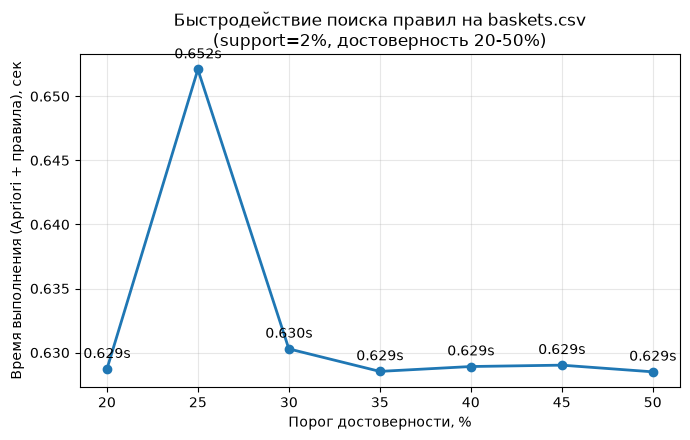

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(experiments_df["min_confidence_%"], experiments_df["time_sec"],
        marker="o", linewidth=2)
ax.set_xlabel("Порог достоверности, %")
ax.set_ylabel("Время выполнения (Apriori + правила), сек")
ax.set_title("Быстродействие поиска правил на baskets.csv\n(support=2%, достоверность 20-50%)")
ax.grid(True, alpha=0.3)

for x, y in zip(experiments_df["min_confidence_%"], experiments_df["time_sec"]):
    ax.annotate(f"{y:.3f}s", (x, y), textcoords="offset points", xytext=(0, 8), ha="center")

plt.tight_layout()
plt.savefig("runtime_vs_confidence.png", dpi=150)
plt.show()


## 7. Визуализация: количество правил в зависимости от порога достоверности

Ожидаем монотонно убывающую кривую: чем выше требуемая достоверность,
тем меньше правил проходит фильтр.


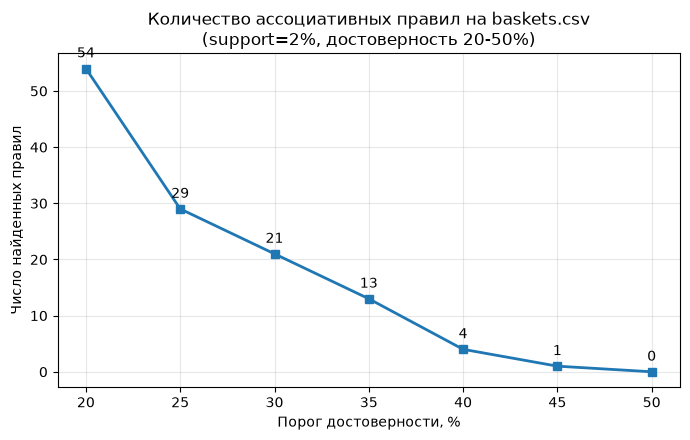

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(experiments_df["min_confidence_%"], experiments_df["n_rules"],
        marker="s", linewidth=2)
ax.set_xlabel("Порог достоверности, %")
ax.set_ylabel("Число найденных правил")
ax.set_title("Количество ассоциативных правил на baskets.csv\n(support=2%, достоверность 20-50%)")
ax.grid(True, alpha=0.3)

for x, y in zip(experiments_df["min_confidence_%"], experiments_df["n_rules"]):
    ax.annotate(f"{y}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center")

plt.tight_layout()
plt.savefig("rules_count_vs_confidence.png", dpi=150)
plt.show()


## 8. Список правил и содержательный анализ

Фиксируем поддержку 2% и достоверность 30% - получаем 21 правило
(разумное количество для ручного разбора). Все правила короткие:
антецедент + консеквент = 2 объекта (≤ 7 по требованию задания).


In [10]:
final_rules = generate_rules(
    apriori(transactions, min_support=0.02, sort_by="support_desc"),
    min_confidence=0.30, sort_by="support_desc")
print(f"Итого правил (support=2%, confidence=30%): {len(final_rules)}\n")
for i, (ant, cons, sup, conf) in enumerate(final_rules, 1):
    print(f"{i:2d}. " + format_rule(ant, cons, sup, conf))


Итого правил (support=2%, confidence=30%): 21

 1. {макароны} -> {минеральная вода}  support=0.0612  confidence=0.3255
 2. {шоколад} -> {минеральная вода}  support=0.0527  confidence=0.3214
 3. {молоко} -> {минеральная вода}  support=0.0480  confidence=0.3704
 4. {говяжий фарш} -> {минеральная вода}  support=0.0409  confidence=0.4166
 5. {говяжий фарш} -> {макароны}  support=0.0403  confidence=0.4098
 6. {замороженные овощи} -> {минеральная вода}  support=0.0357  confidence=0.3748
 7. {блинчики} -> {минеральная вода}  support=0.0337  confidence=0.3548
 8. {гамбургер} -> {яйца}  support=0.0288  confidence=0.3303
 9. {оливковое масло} -> {минеральная вода}  support=0.0276  confidence=0.4190
10. {торт} -> {минеральная вода}  support=0.0275  confidence=0.3388
11. {рис} -> {минеральная вода}  support=0.0273  confidence=0.3596
12. {креветки} -> {макароны}  support=0.0252  confidence=0.3526
13. {помидоры} -> {минеральная вода}  support=0.0244  confidence=0.3567
14. {низкокалорийный йогурт} ->

### Что означают эти правила

- **«Минеральная вода» - универсальный консеквент.** 17 из 21 правила
  предсказывают именно её. Это не сильная смысловая связь, а следствие
  популярности товара: вода - лидер продаж (поддержка 23.8%), поэтому
  условная вероятность «если в чеке есть X, то там есть и вода» повышена
  для многих X. Поддержка правил 0.02-0.06, достоверность 0.31-0.46 -
  умеренные значения, типичные для разреженных корзин.
- **Самые достоверные правила:** `суп → минеральная вода` (conf 0.456),
  `оливковое масло → минеральная вода` (0.419),
  `говяжий фарш → минеральная вода` (0.417),
  `говяжий фарш → макароны` (0.410). Первые три - «водные»,
  а четвёртое - продуктово осмысленное: фарш и макароны покупают вместе
  для приготовления горячих блюд (паста болоньезе, макароны по-флотски).
- **Продуктовые связки:** `креветки → макароны` (0.353),
  `оливковое масло → макароны` (0.360), `помидоры → макароны` (0.316),
  `гамбургер → яйца` (0.330) - все они описывают совместное
  приготовление: паста с морепродуктами/соусом, яичные блюда к фастфуду.
- **Почему при 10% / 70%+ правил нет.** На данном наборе максимальная
  достоверность частых при 2% пар - около 0.46, а при поддержке 10%
  парных наборов нет вообще. Высокие пороги из примера задания
  рассчитаны на более плотные данные; для `baskets.csv` рабочие диапазоны -
  поддержка порядка единиц процентов и достоверность 20-50%.


## 9. Выводы

- Программа из работы №1 доработана: добавлен модуль генерации правил
  с порогом достоверности и двумя режимами сортировки (по поддержке,
  лексикографически); вывод - в удобочитаемом виде
  `{антецедент} -> {консеквент}  support=...  confidence=...`.
- При поддержке 10% и достоверности 70-95% правил нет (0 во всех точках):
  это воспроизводимый результат, объясняемый разреженностью чеков.
- При поддержке 2% число правил монотонно падает с ростом порога
  достоверности (54 → 0 на отрезке 20-50%), а время работы почти постоянно
  (~0.6 c): фильтрация по достоверности дёшева, доминирует Apriori.
- Содержательно правила описывают «эффект популярного товара»
  (минеральная вода как консеквент) плюс несколько продуктовых связок
  (фарш-макароны, креветки-макароны, гамбургер-яйца), пригодных,
  например, для совместной выкладки и рекомендаций.
